# ETS MARL — Multi-Agent RL for EU Emissions Trading

**Technology-Specific Energy Mix | Real CapEx | Construction Queues | PPO**

This notebook is a testing playground for the ETS MARL simulation.
It clones the repository, installs dependencies, runs tests, trains agents,
and visualizes results — all within Google Colab.

---

### Model Overview (v5.0)
- **8 agents** representing European electricity utilities (10 TWh/year each)
  - 4 archetypes × 2 replicas: coal-heavy, gas-dominant, mixed, near-green
- **5 technologies**: Coal, Gas CCGT, Onshore Wind, Offshore Wind, Solar PV
- **Real-data-grounded** CapEx (IRENA 2024), emission factors (IPCC AR5), deployment delays
- **EU ETS mechanics**: uniform-price auction, MSR, LRF (Fit for 55), 100% auctioning
- **PPO agents** with two-phase decisions (auction + secondary market)
- **Greening-only** constraint: agents can only add renewables, fossil can only decrease
- **MAC fuel-switching**: automatic coal→gas dispatch switching at marginal cost (€65/tCO₂)
- **Electricity revenue**: margin-based reward (output × electricity price)
- **Carry-forward obligations**: non-compliance shortfall added to next year's surrender
- **Soft agent cycling**: all agents learn every episode (non-active at reduced LR)

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/DJH961/Thesis-Energy-Auction.git"
BRANCH = "third-version"
PROJECT_SUBDIR = "ets_marl ppo"

def _is_project_root(path: Path) -> bool:
    return (path / "src").is_dir() and (path / "configs").is_dir()

# Se hai indicato una repo, usa quella come fonte di verità
if REPO_URL:
    os.chdir("/content")

    repo_name = Path(REPO_URL.rstrip("/")).name.replace(".git", "")
    clone_dir = Path("/content") / repo_name

    if clone_dir.exists():
        print(f"Removing existing clone: {clone_dir}")
        subprocess.run(["rm", "-rf", str(clone_dir)], check=False)

    clone_cmd = ["git", "clone", "-b", BRANCH, REPO_URL, str(clone_dir)]
    print("Cloning:", " ".join(clone_cmd))
    subprocess.run(clone_cmd, check=True)

    # 1) prova esplicitamente la sottocartella richiesta
    if PROJECT_SUBDIR:
        target = clone_dir / PROJECT_SUBDIR
        if not _is_project_root(target):
            raise FileNotFoundError(
                f"PROJECT_SUBDIR non valido: {target}\n"
                f"Contenuto repo: {os.listdir(clone_dir)}"
            )
        os.chdir(target)
    else:
        # 2) altrimenti prova root repo, poi una cartella sotto
        candidates = [clone_dir] + [p for p in clone_dir.iterdir() if p.is_dir()]
        found = None
        for cand in candidates:
            if _is_project_root(cand):
                found = cand
                break
        if found is None:
            raise FileNotFoundError(
                f"Non trovo src/ e configs/ dentro {clone_dir}\n"
                f"Contenuto repo: {os.listdir(clone_dir)}"
            )
        os.chdir(found)

else:
    # fallback locale
    local_candidates = [Path("."), Path(".."), Path("../..")]
    found = None
    for cand in local_candidates:
        if _is_project_root(cand):
            found = cand
            break
    if found is None:
        raise FileNotFoundError(
            "Cannot find project root locally. Set REPO_URL in this cell."
        )
    os.chdir(found)

sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())
!git branch --show-current
!git log -1 --oneline
print("Files here:", os.listdir("."))

Cloning: git clone -b third-version https://github.com/DJH961/Thesis-Energy-Auction.git /content/Thesis-Energy-Auction
Working directory: /content/Thesis-Energy-Auction/ets_marl ppo
third-version
8877c49 (HEAD -> third-version, origin/third-version) Add files via upload
Files here: ['README.md', 'main.py', 'install.bat', 'src', 'setup.sh', 'docs', 'configs', 'requirements.txt', 'uv.lock', 'pyproject.toml', 'scripts', 'tests', 'notebooks']


## 1. Setup — Clone Repository & Install Dependencies

In [2]:
# Install dependencies
if os.path.exists("requirements.txt"):
    !pip install -q -r requirements.txt
else:
    !pip install -q gymnasium numpy torch pyyaml pandas matplotlib seaborn pytest numpy-groupies

# Verify GPU availability
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 2.7 MB/s eta 0:00:00
PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Run Tests — Verify Everything Works

In [3]:
!python -m pytest tests/ -v

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/Thesis-Energy-Auction/ets_marl ppo
configfile: pyproject.toml
plugins: anyio-4.12.1, typeguard-4.5.1, langsmith-0.7.7
collected 38 items                                                             

tests/test_cap_schedule.py::test_cap_year_0 PASSED                       [  2%]
tests/test_cap_schedule.py::test_cap_year_1_lrf_phase1 PASSED            [  5%]
tests/test_cap_schedule.py::test_cap_year_5_switches_to_phase2 PASSED    [  7%]
tests/test_cap_schedule.py::test_cap_strictly_decreasing PASSED          [ 10%]
tests/test_cap_schedule.py::test_cap_year_10 PASSED                      [ 13%]
tests/test_cap_schedule.py::test_msr_no_adjustment_within_band PASSED    [ 15%]
tests/test_cap_schedule.py::test_msr_withhold_when_tnac_high PASSED      [ 18%]
tests/test_cap_schedule.py::test_msr_

## 3. Explore the Environment

In [4]:
import os, yaml
print("CWD:", os.getcwd())

with open("configs/default.yaml") as f:
    config = yaml.safe_load(f)

print("Config keys:", list(config.keys()))

CWD: /content/Thesis-Energy-Auction/ets_marl ppo
Config keys: ['simulation', 'technologies', 'ets', 'companies', 'investment', 'risk', 'auction', 'trading', 'budget', 'penalty', 'price', 'mac', 'electricity', 'reward', 'opponent_modeling', 'agent_cycling', 'ppo', 'uncertainty', 'construction_jitter', 'warm_start', 'logging', 'pretrain', 'diagnostics']


In [5]:
import sys
sys.path.insert(0, '.')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.environment.ets_environment import ETSEnvironment

with open('configs/default.yaml') as f:
    config = yaml.safe_load(f)

env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset()

tech_names = config['technologies']['names']

print('=== Environment Summary ===')
print(f'Agents: {env.n_agents}')
print(f'Years: {env.n_years}')
print(f'Technologies: {tech_names}')
print(f'Phase 1 obs dim: {obs1.shape[1]}')
print(f'Initial cap: {env.cap_schedule.get_cap(0):.2f} Mt')
print()

for i, c in enumerate(env.companies):
    mix_str = ' | '.join([f'{tech_names[t]}: {c.mix[t]*100:.0f}%' for t in range(len(tech_names))])
    print(f'A{i+1}: {mix_str}')
    print(f'     Emissions: {c.compute_emissions():.2f} Mt | '
          f'Green: {c.green_frac*100:.0f}% | '
          f'Op. Cost: {c.compute_operational_cost():.0f} M€/yr | '
          f'Avg EF: {c.weighted_emission_factor:.3f} tCO2/MWh')


=== Environment Summary ===
Agents: 8
Years: 12
Technologies: ['coal', 'gas', 'onshore_wind', 'offshore_wind', 'solar']
Phase 1 obs dim: 35
Initial cap: 24.00 Mt

A1: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A2: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A3: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A4: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A5: coal: 5% | gas: 25% | onshore_wind: 35% | offshore_wind: 20% | solar: 15%
     Emissions: 1.77 Mt | Green: 70% | Op. Cost: 342 M€/yr | Avg EF: 0.177 tCO2/MWh
A6: coal: 5% | gas: 25% | o

## 4. Run a Random-Policy Episode (Baseline)

In [6]:
env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset(seed=42)
n_agents = env.n_agents
rng = np.random.default_rng(42)

aq = config['auction']
inv = config['investment']
trading_cfg = config.get('trading', {})
qty_mult_low = aq.get('qty_mult_low', 0.3)
qty_mult_high = aq.get('qty_mult_high', 1.3)
sec_mult_low = trading_cfg.get('sec_mult_low', 0.8)
sec_mult_high = trading_cfg.get('sec_mult_high', 1.3)

year_data = []

for year in range(config['simulation']['n_years']):
    # Random auction actions (use config bounds)
    auction_actions = rng.uniform(
        [aq['price_min'], qty_mult_low, 0.0, -1.0, -1.0, -1.0],
        [aq['price_max'], qty_mult_high, inv['max_invest_frac'], 1.0, 1.0, 1.0],
        size=(n_agents, 6)
    ).astype(np.float32)

    obs2, _ = env.step_auction(auction_actions)

    # Random secondary actions (config-driven bounds)
    secondary_actions = rng.uniform(
        [sec_mult_low, -aq['quantity_max']], [sec_mult_high, aq['quantity_max']], size=(n_agents, 2)
    ).astype(np.float32)

    obs1, rewards, terminated, _, info = env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
    year_data.append(row)

    if terminated:
        break

df = pd.DataFrame(year_data)
df

,year,cap,price,green_A1,emissions_A1,green_A2,emissions_A2,green_A3,emissions_A3,green_A4,emissions_A4,green_A5,emissions_A5,green_A6,emissions_A6,green_A7,emissions_A7,green_A8,emissions_A8
0,0,24.000000,161.782349,0.248731,4.244799,0.231070,4.369766,0.422741,2.916399,0.439737,2.831820,0.700000,1.604500,0.700000,1.604500,0.923777,0.579908,0.914507,0.620881
1,1,22.968000,86.974998,0.334590,3.581962,0.231070,4.369766,0.441391,2.833966,0.469776,2.693015,0.762998,1.322025,0.700000,1.604500,0.946467,0.479614,0.923042,0.579996
2,2,21.980376,62.439854,0.378287,3.894411,0.331076,4.252383,0.441391,3.192376,0.488144,2.809156,0.769799,1.291965,0.750104,1.383039,0.960455,0.417790,0.936358,0.521139
3,3,21.035220,59.641270,0.398510,3.730808,0.345410,4.136418,0.441391,3.192376,0.532035,2.470317,0.775965,1.262430,0.750104,1.383039,1.000000,0.241392,0.936358,0.521139
4,4,20.109670,46.956009,0.413838,3.612473,0.345410,4.136418,0.518740,2.566843,0.532035,2.470317,0.796643,1.163589,0.750104,1.383039,1.000000,0.237989,0.959639,0.409760
5,5,19.224845,162.227737,0.437553,2.887006,0.345410,3.476418,0.568620,2.227247,0.532035,2.411033,0.796643,1.163589,0.793461,1.175686,1.000000,0.237989,0.985236,0.287152
6,6,18.378952,100.217514,0.437553,2.887006,0.345410,3.476418,0.595013,2.105715,0.534306,2.400177,0.796643,1.163589,0.822106,1.038478,1.000000,0.237989,1.000000,0.213133
7,7,17.570278,54.675362,0.437553,3.423079,0.441266,3.361902,0.640868,1.903037,0.534306,2.451965,0.796643,1.163589,0.836408,0.975263,1.000000,0.237989,1.000000,0.213133
8,8,16.797185,48.890865,0.437553,3.423079,0.441266,3.361902,0.640868,1.903037,0.548047,2.340802,0.796643,1.163589,0.892903,0.704651,1.000000,0.237989,1.000000,0.213133
9,9,16.058109,56.796753,0.470966,3.165131,0.500092,2.886001,0.640868,1.903037,0.548047,2.340802,0.820318,1.050425,0.945278,0.454298,1.000000,0.237989,1.000000,0.209520


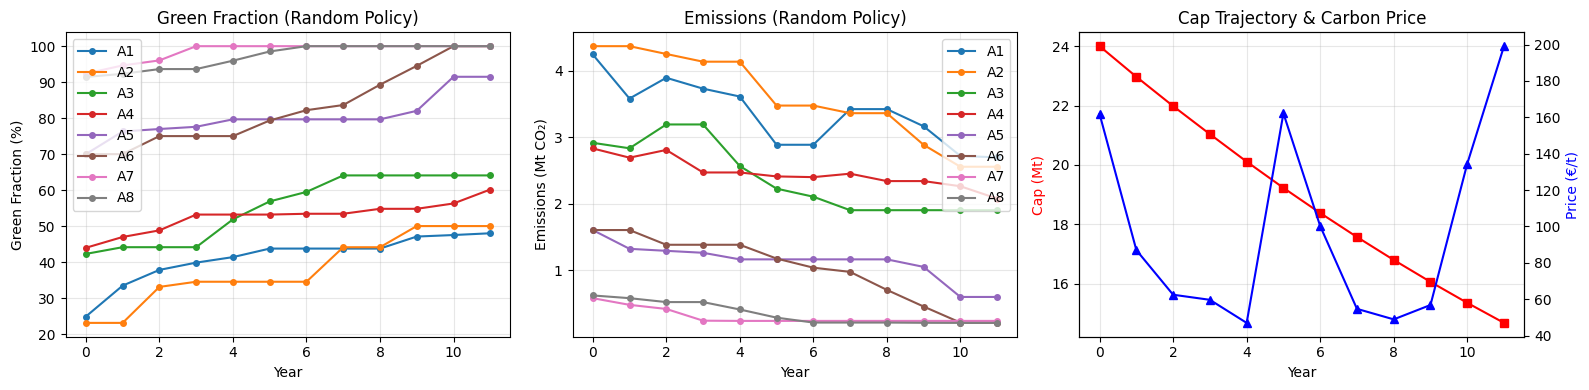

In [7]:
# Plot: Green fraction evolution (random policy)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Green fracs
ax = axes[0]
for i in range(n_agents):
    ax.plot(df['year'], df[f'green_A{i+1}'] * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Fraction (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Emissions
ax = axes[1]
for i in range(n_agents):
    ax.plot(df['year'], df[f'emissions_A{i+1}'], label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt CO₂)')
ax.set_title('Emissions (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Cap & Price
ax = axes[2]
ax.plot(df['year'], df['cap'], label='Cap (Mt)', marker='s', color='red')
ax2 = ax.twinx()
ax2.plot(df['year'], df['price'], label='Price (€/t)', marker='^', color='blue')
ax.set_xlabel('Year')
ax.set_ylabel('Cap (Mt)', color='red')
ax2.set_ylabel('Price (€/t)', color='blue')
ax.set_title('Cap Trajectory & Carbon Price')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Train PPO Agents (Short Run)

In [8]:
import copy
from scripts.train import train_one_seed

# Override for quick Colab run (reduce episodes)
train_config = copy.deepcopy(config)
train_config['simulation']['n_episodes'] = 1500
train_config['logging']['log_interval'] = 49
train_config['logging']['save_interval'] = 100

train_one_seed(train_config, seed=42)



Training — seed 42, 8 agents, PPO, two-phase
v5.0: MAC switching | Electricity revenue | Carry-forward
P1-P8 + structural improvements active

──────────────────────────────────────────────────────────────────────────────────
TRAINING CONSOLE — COLUMN GUIDE
──────────────────────────────────────────────────────────────────────────────────
Market header  (printed every log_interval episodes)
  price X→Y (peak Z) : ETS clearing price yr-0 → yr-N and peak  (€/t)
  cap                : Cap (Mt) in the final year
  TNAC               : Total allowances in circulation, final year
  sec_price/vol/match: Secondary market stats
  entropy/shaping    : PPO entropy coef & green-shaping weight
  [ENT-DECAY]        : Entropy decay triggered
  [cyc=Ax]           : Active agent (soft cycling)

Per-agent columns
  Green(0→N)  : Green fraction trajectory
  ΔGreen      : Net green change (pp)
  AvgEmiss    : Mean emissions (Mt)
  AvgAlloc    : Mean allocation (Mt)
  SfYrs       : Shortfall years
  AvgBi

## 6. Analyze Training Results

In [9]:
# Load training logs
ep_df = pd.read_csv('results/training_log_s42.csv')
yr_df = pd.read_csv('results/year_log_s42.csv')

print(f'Training episodes: {len(ep_df)}')
print(f'Year-level records: {len(yr_df)}')
ep_df.tail()

Training episodes: 1500
Year-level records: 18000


,episode,clearing_price_last,cap_last,entropy_coef,shaping_weight,entropy_decay_triggered,active_agent,reward_A1,green_frac_A1,delta_green_A1,...,total_cancels_A7,total_holding_cost_A7,total_mac_reduction_A7,mean_alloc_A8,mean_shock_A8,max_shock_A8,mean_cf_shock_A8,total_cancels_A8,total_holding_cost_A8,total_mac_reduction_A8
1495,1495,50.307365,14.676084,0.005,0.7010,1,7,-1.3386,0.2923,0.09232,...,0,0.0082,0.0,0.3776,0.0,0.0,0.0,0,0.0621,0.0
1496,1496,42.427872,14.676084,0.005,0.7008,1,0,5.4636,0.3904,0.19036,...,0,0.0094,0.0,0.4632,0.0,0.0,0.0,0,0.0148,0.0
1497,1497,40.774124,14.676084,0.005,0.7006,1,1,5.4299,0.3309,0.13092,...,0,0.0030,0.0,0.5710,0.0,0.0,0.0,0,0.0231,0.0
1498,1498,42.610023,14.676084,0.005,0.7004,1,2,-0.7145,0.2470,0.04698,...,0,0.0000,0.0,0.6520,0.0,0.0,0.0,0,0.0410,0.0
1499,1499,40.169205,14.676084,0.005,0.7002,1,3,4.3995,0.3631,0.16308,...,0,0.0273,0.0,0.3779,0.0,0.0,0.0,0,0.0189,0.0


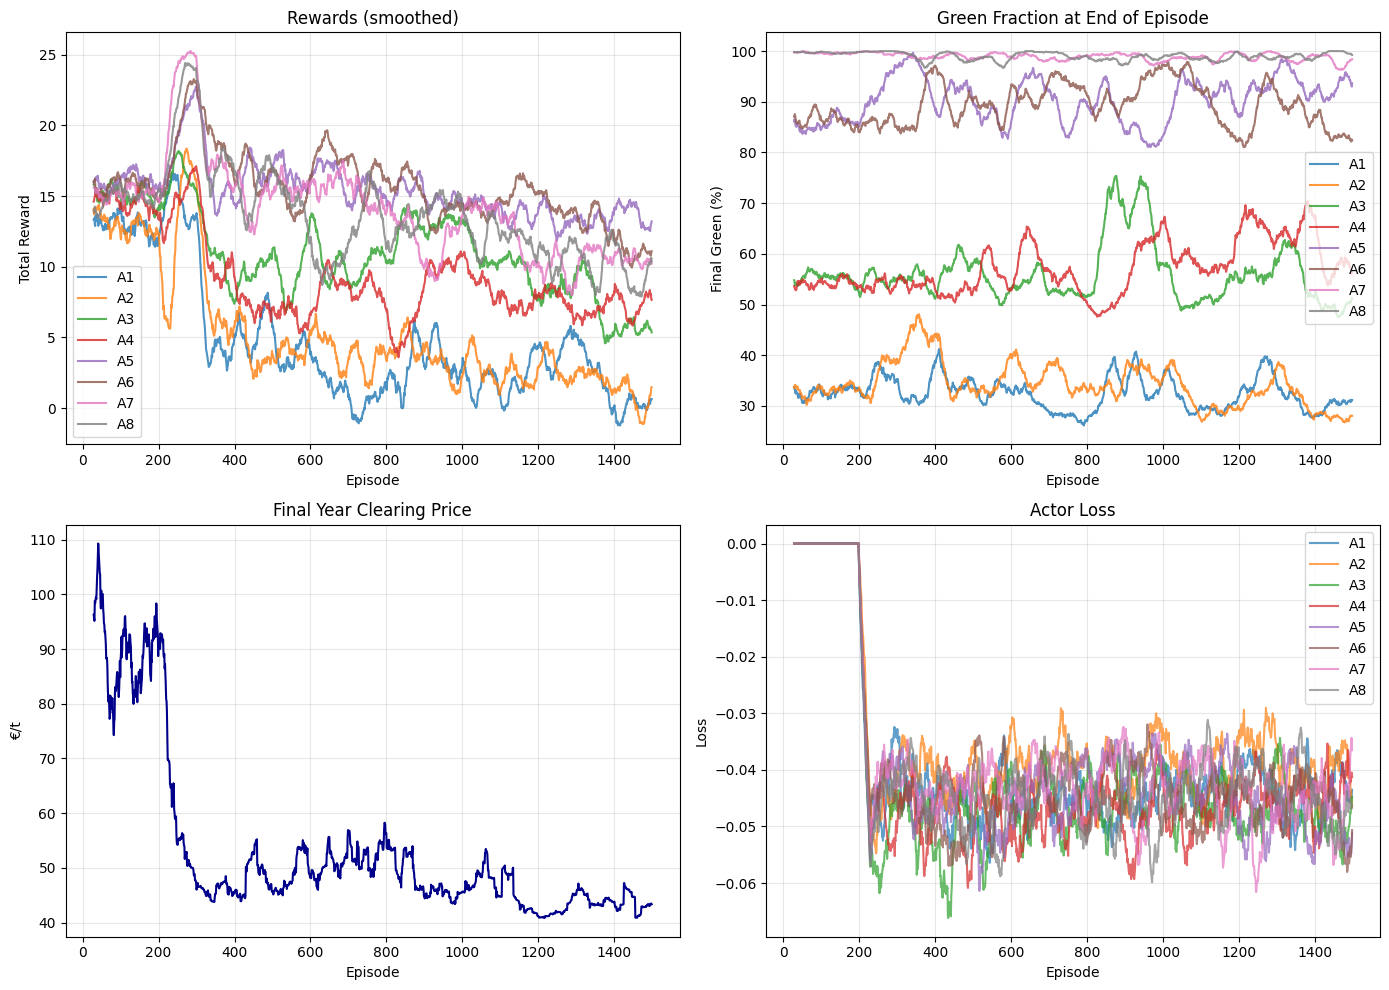

In [10]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
n_agents = config['companies']['n_agents']
window = max(1, len(ep_df) // 50)  # smoothing window

# 1. Rewards
ax = axes[0, 0]
for i in range(n_agents):
    col = f'reward_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Rewards (smoothed)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Green fractions
ax = axes[0, 1]
for i in range(n_agents):
    col = f'green_frac_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean() * 100, label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Final Green (%)')
ax.set_title('Green Fraction at End of Episode')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Clearing price
ax = axes[1, 0]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(window).mean(), color='darkblue')
ax.set_xlabel('Episode')
ax.set_ylabel('€/t')
ax.set_title('Final Year Clearing Price')
ax.grid(True, alpha=0.3)

# 4. Actor loss
ax = axes[1, 1]
for i in range(n_agents):
    col = f'actor_loss_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Actor Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

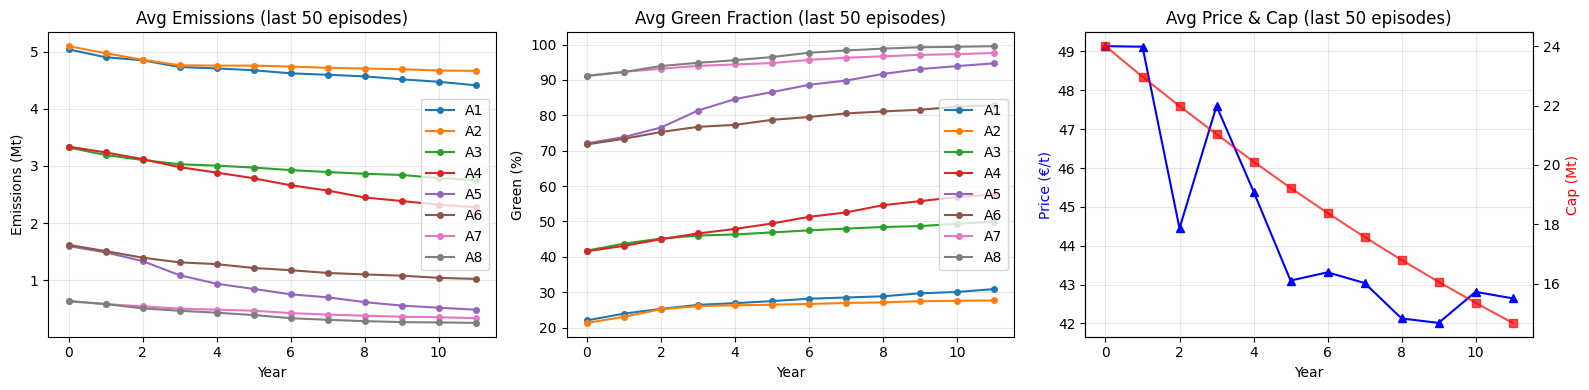

In [11]:
# Year-level analysis: last 50 episodes
last_eps = yr_df['episode'].unique()[-50:]
recent = yr_df[yr_df['episode'].isin(last_eps)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Emissions by year (averaged over recent episodes)
ax = axes[0]
for i in range(n_agents):
    avg = recent.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(avg.index, avg.values, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt)')
ax.set_title('Avg Emissions (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Green frac by year
ax = axes[1]
for i in range(n_agents):
    avg = recent.groupby('year')[f'green_frac_A{i+1}'].mean()
    ax.plot(avg.index, avg.values * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green (%)')
ax.set_title('Avg Green Fraction (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Carbon price trajectory
ax = axes[2]
avg_price = recent.groupby('year')['clearing_price'].mean()
avg_cap = recent.groupby('year')['cap'].mean()
ax.plot(avg_price.index, avg_price.values, label='Clearing Price', marker='^', color='blue')
ax2 = ax.twinx()
ax2.plot(avg_cap.index, avg_cap.values, label='Cap', marker='s', color='red', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Price (€/t)', color='blue')
ax2.set_ylabel('Cap (Mt)', color='red')
ax.set_title('Avg Price & Cap (last 50 episodes)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6b. P5–P8 & MAC Stochastic Deviation Analysis

Visualise the **random noise** and **abatement mechanisms** across training:
- **P5** — Emission demand shocks (ε ~ correlated normal, σ=7%)
- **P6** — Green capacity-factor noise + project cancellations
- **P8** — Banking holding costs (penalty for excess allowance hoarding)
- **MAC** — Fuel-switching abatement (coal→gas dispatch when carbon price > €65/t)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


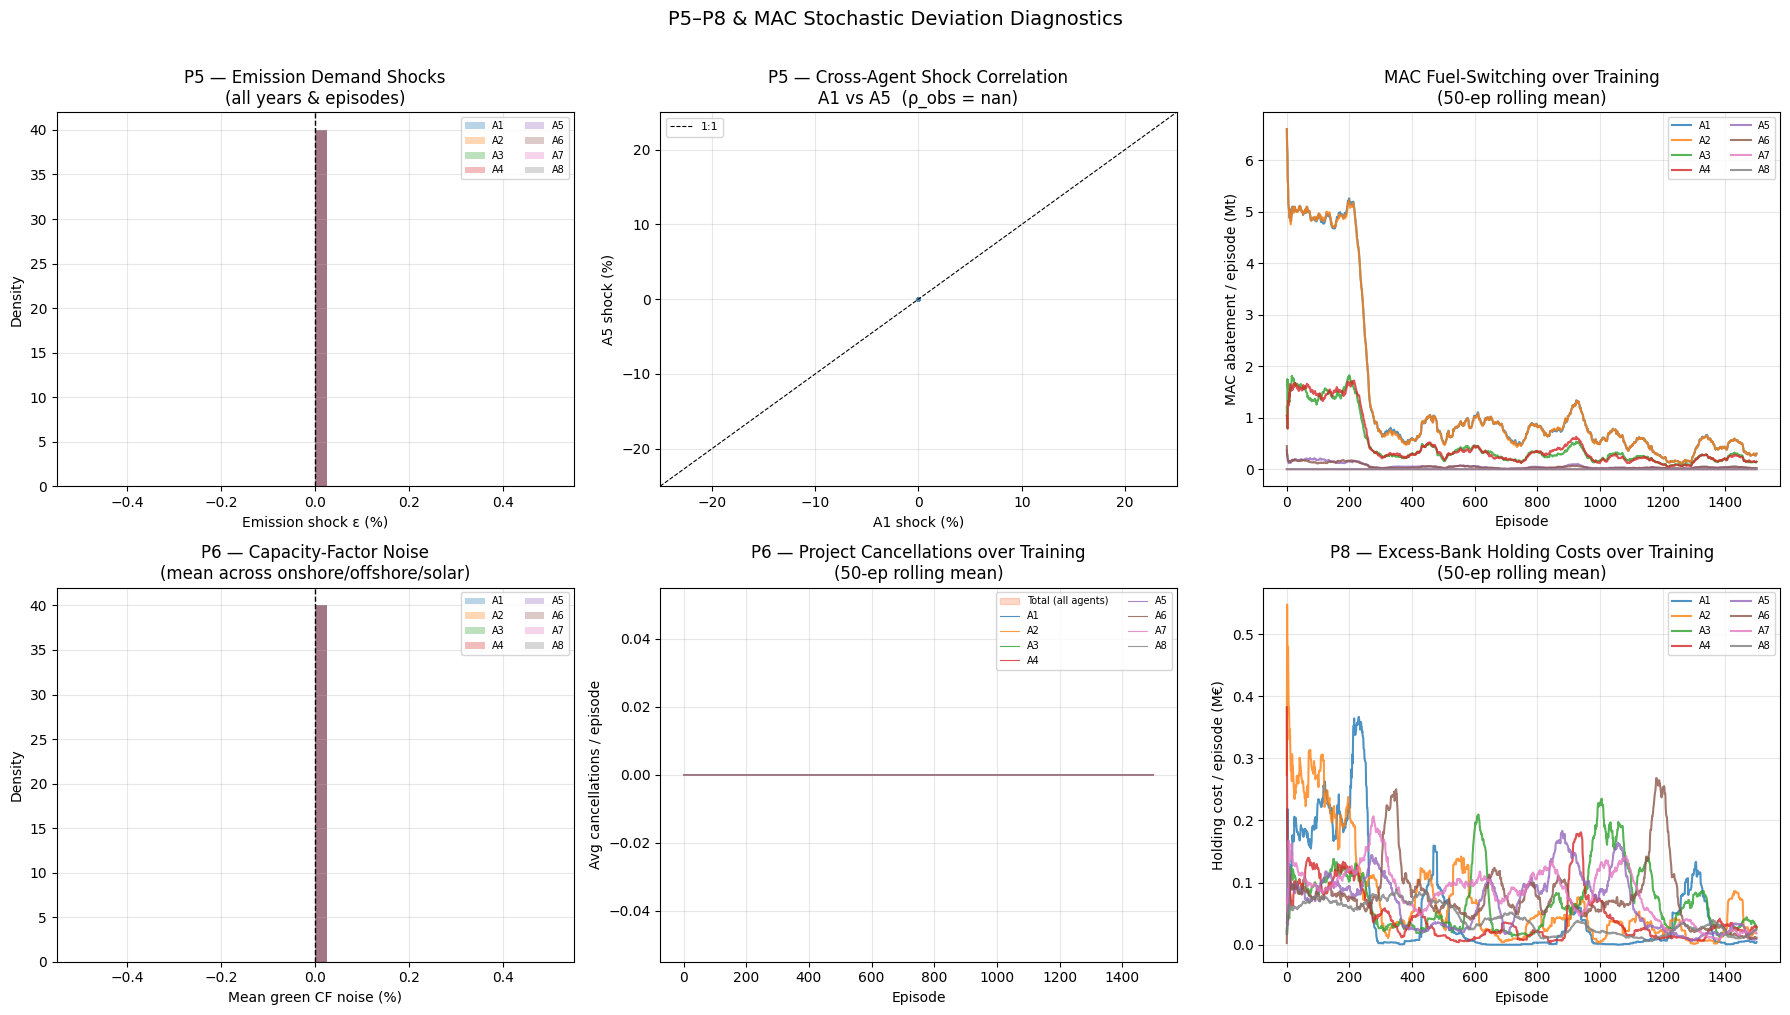


─── P5/P6/P8/MAC deviation summary (all training data) ───
    ε_mean (%)  ε_std (%)  CF_noise_std (%)  cancels_total  holdcost_sum (M€)  mac_total (Mt)
A1         0.0        0.0               0.0            0.0              81.90         1914.91
A2         0.0        0.0               0.0            0.0             103.83         1908.75
A3         0.0        0.0               0.0            0.0             106.64          660.52
A4         0.0        0.0               0.0            0.0              64.32          672.05
A5         0.0        0.0               0.0            0.0              99.06           81.29
A6         0.0        0.0               0.0            0.0             117.59           73.56
A7         0.0        0.0               0.0            0.0             122.68            0.00
A8         0.0        0.0               0.0            0.0              61.29            0.00


In [12]:
# ── P5/P6/P8 stochastic deviation analysis ─────────────────────────────────
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']
tech_names = config['technologies']['names']

# Check which deviation columns exist
shock_cols    = [f'emission_shock_A{i+1}' for i in range(n_agents)]
cf_cols       = [f'cf_shock_A{i+1}'       for i in range(n_agents)]
cancel_cols   = [f'cancellation_A{i+1}'   for i in range(n_agents)]
hcost_cols    = [f'holding_cost_A{i+1}'   for i in range(n_agents)]
mac_cols      = [f'mac_reduction_A{i+1}'  for i in range(n_agents)]

has_deviations = all(c in yr_df.columns for c in shock_cols)
has_mac = all(c in yr_df.columns for c in mac_cols)

cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i % 10) for i in range(n_agents)]
leg_ncol = max(1, n_agents // 4)
bar_alpha = max(0.25, 0.55 - n_agents * 0.03)  # reduce opacity with more agents

if not has_deviations:
    print('Deviation columns not found — re-run training with the updated train.py')
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # ── 1. P5 emission shock distribution (all agents, all years) ────────────
    ax = axes[0, 0]
    for i in range(n_agents):
        vals = yr_df[shock_cols[i]] * 100
        ax.hist(vals, bins=40, alpha=bar_alpha, label=f'A{i+1}',
                density=True, color=agent_colors[i])
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Emission shock ε (%)')
    ax.set_ylabel('Density')
    ax.set_title('P5 — Emission Demand Shocks\n(all years & episodes)')
    ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 2. P5 shock correlation check (A1 vs A(n//2) — spread archetypes) ────
    ax = axes[0, 1]
    idx_a, idx_b = 0, max(1, n_agents // 2)
    ax.scatter(yr_df[shock_cols[idx_a]] * 100, yr_df[shock_cols[idx_b]] * 100,
               alpha=0.15, s=4, color='steelblue')
    lims = [-25, 25]
    ax.plot(lims, lims, 'k--', lw=0.8, label='1:1')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'A{idx_a+1} shock (%)')
    ax.set_ylabel(f'A{idx_b+1} shock (%)')
    corr = yr_df[shock_cols[idx_a]].corr(yr_df[shock_cols[idx_b]])
    ax.set_title(f'P5 — Cross-Agent Shock Correlation\nA{idx_a+1} vs A{idx_b+1}  (ρ_obs = {corr:.2f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── 3. MAC fuel-switching over training ──────────────────────────────────
    ax = axes[0, 2]
    if has_mac:
        ep_mac = (
            yr_df.groupby('episode')[[*mac_cols]]
            .sum()
            .rolling(50, min_periods=1)
            .mean()
        )
        for i in range(n_agents):
            ax.plot(ep_mac.index, ep_mac[mac_cols[i]],
                    label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
        ax.set_xlabel('Episode')
        ax.set_ylabel('MAC abatement / episode (Mt)')
        ax.set_title('MAC Fuel-Switching over Training\n(50-ep rolling mean)')
        ax.legend(fontsize=7, ncol=leg_ncol)
    else:
        # Fallback: P5 shock volatility
        ep_shock_std = (
            yr_df.groupby('episode')[[*shock_cols]]
            .std()
            .rolling(50, min_periods=1)
            .mean()
        )
        for i in range(n_agents):
            ax.plot(ep_shock_std.index, ep_shock_std[shock_cols[i]] * 100,
                    label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
        ax.axhline(7.0, color='k', ls='--', lw=0.8, label='σ_demand=7%')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Within-episode shock std (%)')
        ax.set_title('P5 — Emission Shock Volatility over Training')
        ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 4. P6 CF noise distribution (green techs averaged) ───────────────────
    ax = axes[1, 0]
    for i in range(n_agents):
        vals = yr_df[cf_cols[i]] * 100
        ax.hist(vals, bins=40, alpha=bar_alpha, label=f'A{i+1}',
                density=True, color=agent_colors[i])
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Mean green CF noise (%)')
    ax.set_ylabel('Density')
    ax.set_title('P6 — Capacity-Factor Noise\n(mean across onshore/offshore/solar)')
    ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 5. P6 project cancellations over training ─────────────────────────────
    ax = axes[1, 1]
    ep_cancels = (
        yr_df.groupby('episode')[[*cancel_cols]]
        .sum()
        .rolling(50, min_periods=1)
        .mean()
    )
    ep_cancels['total'] = ep_cancels[cancel_cols].sum(axis=1)
    ax.fill_between(ep_cancels.index, ep_cancels['total'],
                    alpha=0.3, color='coral', label='Total (all agents)')
    for i in range(n_agents):
        ax.plot(ep_cancels.index, ep_cancels[cancel_cols[i]],
                lw=0.8, label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
    ax.set_xlabel('Episode')
    ax.set_ylabel('Avg cancellations / episode')
    ax.set_title('P6 — Project Cancellations over Training\n(50-ep rolling mean)')
    ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 6. P8 holding cost over training ─────────────────────────────────────
    ax = axes[1, 2]
    has_hcost = all(c in yr_df.columns for c in hcost_cols)
    if has_hcost:
        ep_hcost = (
            yr_df.groupby('episode')[[*hcost_cols]]
            .sum()
            .rolling(50, min_periods=1)
            .mean()
        )
        for i in range(n_agents):
            ax.plot(ep_hcost.index, ep_hcost[hcost_cols[i]],
                    label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
        ax.set_xlabel('Episode')
        ax.set_ylabel('Holding cost / episode (M€)')
        ax.set_title('P8 — Excess-Bank Holding Costs over Training\n(50-ep rolling mean)')
        ax.legend(fontsize=7, ncol=leg_ncol)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'holding_cost columns\nnot found in CSV',
                ha='center', va='center', transform=ax.transAxes)

    plt.suptitle('P5–P8 & MAC Stochastic Deviation Diagnostics', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Summary statistics table
    print('\n─── P5/P6/P8/MAC deviation summary (all training data) ───')
    summary = {}
    for i in range(n_agents):
        row = {
            'ε_mean (%)':       round(yr_df[shock_cols[i]].mean()  * 100, 3),
            'ε_std (%)':        round(yr_df[shock_cols[i]].std()   * 100, 3),
            'CF_noise_std (%)': round(yr_df[cf_cols[i]].std()      * 100, 3),
            'cancels_total':    int(yr_df[cancel_cols[i]].sum()),
            'holdcost_sum (M€)': round(yr_df[hcost_cols[i]].sum(), 2) if has_hcost else 'n/a',
        }
        if has_mac:
            row['mac_total (Mt)'] = round(yr_df[mac_cols[i]].sum(), 2)
        summary[f'A{i+1}'] = row
    print(pd.DataFrame(summary).T.to_string())


## 6c. Year-by-Year Trajectory Analysis (last N episodes)

Slices the **year_log** to show how behaviour evolves *within* an episode across years 0–9.
Uses the last 100 episodes so the plots represent mature policy behaviour, not early exploration.

Four panels per row:
1. **Allocation vs Emissions** — over-allocation → surplus banking; under-allocation → shortfall risk  
2. **Banking** — bank_start and bank_end per year to see carry-forward dynamics  
3. **Secondary market net** — positive = net seller (revenue), negative = net buyer (cost)  
4. **Compliance surplus / shortfall** — pre-compliance headroom; negative → penalty risk

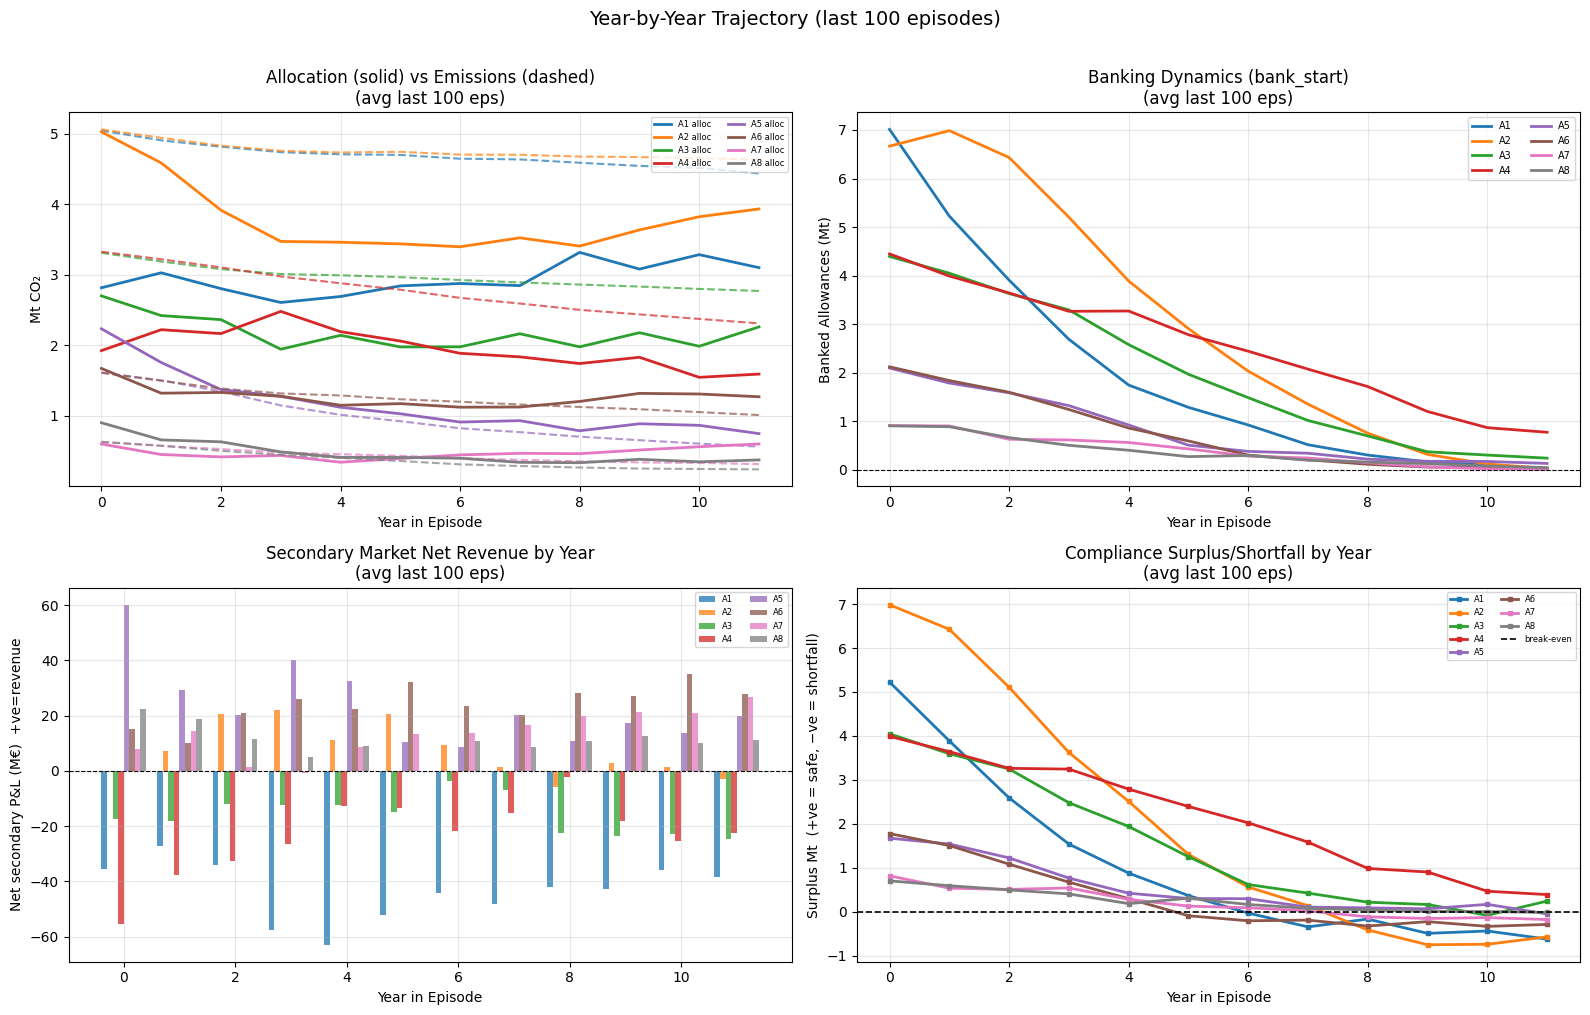


── Average yearly cost breakdown (last 100 eps, all agents combined) ──
      A1_auc(M€)  A1_inv(M€)  A1_pen(M€)  A2_auc(M€)  A2_inv(M€)  A2_pen(M€)  A3_auc(M€)  A3_inv(M€)  A3_pen(M€)  A4_auc(M€)  A4_inv(M€)  A4_pen(M€)  A5_auc(M€)  A5_inv(M€)  A5_pen(M€)  A6_auc(M€)  A6_inv(M€)  A6_pen(M€)  A7_auc(M€)  A7_inv(M€)  A7_pen(M€)  A8_auc(M€)  A8_inv(M€)  A8_pen(M€)
year                                                                                                                                                                                                                                                                                                
0         145.90        7.95        0.00      326.79        8.65        0.00      144.56        4.81        0.15       78.13       56.11        0.15      125.40      175.91       11.77       84.86       37.57        6.50       31.87       16.49        9.13       48.09       28.54       19.06
1         159.18       21.06        2.08      25

In [13]:
# ── 6c: Year-by-year trajectory analysis ──────────────────────────────────
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

N_LAST = 100  # episodes to average over
last_eps = yr_df['episode'].unique()[-N_LAST:]
recent = yr_df[yr_df['episode'].isin(last_eps)].copy()

# Check which new columns are present
has_bank_end   = 'bank_end_A1'            in recent.columns
has_sec_net    = 'secondary_net_A1'       in recent.columns
has_surplus    = 'compliance_surplus_A1'  in recent.columns
has_auc_cost   = 'auction_cost_A1'        in recent.columns

cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i) for i in range(n_agents)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Panel 1: Allocation vs Emissions ──────────────────────────────────────
ax = axes[0, 0]
for i in range(n_agents):
    alloc_avg = recent.groupby('year')[f'alloc_A{i+1}'].mean()
    emiss_avg = recent.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(alloc_avg.index, alloc_avg.values,
            color=agent_colors[i], lw=2, label=f'A{i+1} alloc')
    ax.plot(emiss_avg.index, emiss_avg.values,
            color=agent_colors[i], lw=1.5, ls='--', alpha=0.7)
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Mt CO₂')
ax.set_title(f'Allocation (solid) vs Emissions (dashed)\n(avg last {N_LAST} eps)')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 2: Banking dynamics (bank_start and bank_end) ────────────────────
ax = axes[0, 1]
for i in range(n_agents):
    bs = recent.groupby('year')[f'bank_start_A{i+1}'].mean()
    ax.plot(bs.index, bs.values, color=agent_colors[i], lw=2,
            label=f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Banked Allowances (Mt)')
ax.set_title(f'Banking Dynamics (bank_start)\n(avg last {N_LAST} eps)')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 3: Secondary market net (positive = net revenue) ────────────────
ax = axes[1, 0]
if has_sec_net:
    bar_width = 0.8 / n_agents
    for i in range(n_agents):
        avg = recent.groupby('year')[f'secondary_net_A{i+1}'].mean()
        ax.bar(avg.index + i * bar_width - 0.4 + bar_width/2, avg.values,
               width=bar_width, color=agent_colors[i], alpha=0.75, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Year in Episode')
    ax.set_ylabel('Net secondary P&L (M€)  +ve=revenue')
    ax.set_title(f'Secondary Market Net Revenue by Year\n(avg last {N_LAST} eps)')
    ax.legend(fontsize=6, ncol=2)
else:
    for i in range(n_agents):
        avg = recent.groupby('year')[f'trade_cost_A{i+1}'].mean()
        ax.plot(avg.index, -avg.values, color=agent_colors[i], lw=1.5,
                label=f'A{i+1}', marker='o', markersize=3)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Year in Episode')
    ax.set_ylabel('−trade_cost (M€)  +ve=revenue')
    ax.set_title(f'Secondary Net (from trade_cost, last {N_LAST} eps)')
    ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 4: Compliance surplus / shortfall ───────────────────────────────
ax = axes[1, 1]
if has_surplus:
    for i in range(n_agents):
        avg = recent.groupby('year')[f'compliance_surplus_A{i+1}'].mean()
        ax.plot(avg.index, avg.values, color=agent_colors[i], lw=2,
                marker='s', markersize=3, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=1.2, ls='--', label='break-even')
else:
    for i in range(n_agents):
        sf = recent.groupby('year')[f'shortfall_A{i+1}'].mean()
        ax.plot(sf.index, -sf.values, color=agent_colors[i], lw=2,
                marker='s', markersize=3, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=1.2, ls='--')
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Surplus Mt  (+ve = safe, −ve = shortfall)')
ax.set_title(f'Compliance Surplus/Shortfall by Year\n(avg last {N_LAST} eps)')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Year-by-Year Trajectory (last {N_LAST} episodes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Cost breakdown summary per year (if auction_cost logged) ──────────────
if has_auc_cost:
    print(f'\n── Average yearly cost breakdown (last {N_LAST} eps, all agents combined) ──')
    cols_show = {}
    for i in range(n_agents):
        cols_show[f'A{i+1}_auc(M€)'] = recent.groupby('year')[f'auction_cost_A{i+1}'].mean()
        cols_show[f'A{i+1}_inv(M€)'] = recent.groupby('year')[f'invest_cost_A{i+1}'].mean()
        cols_show[f'A{i+1}_pen(M€)'] = recent.groupby('year')[f'penalty_A{i+1}'].mean()
    print(pd.DataFrame(cols_show).round(2).to_string())


## 6d. Episode Consistency & Variance (ribbon plots)

Shows **mean ± 1 std** bands over the last 100 episodes for key year-level signals.
Wide bands → high variance / unstable policy. Narrow bands → consistent behaviour.

Includes a **price ribbon** (year 0→9 trajectory) and per-agent **green fraction trajectory**.

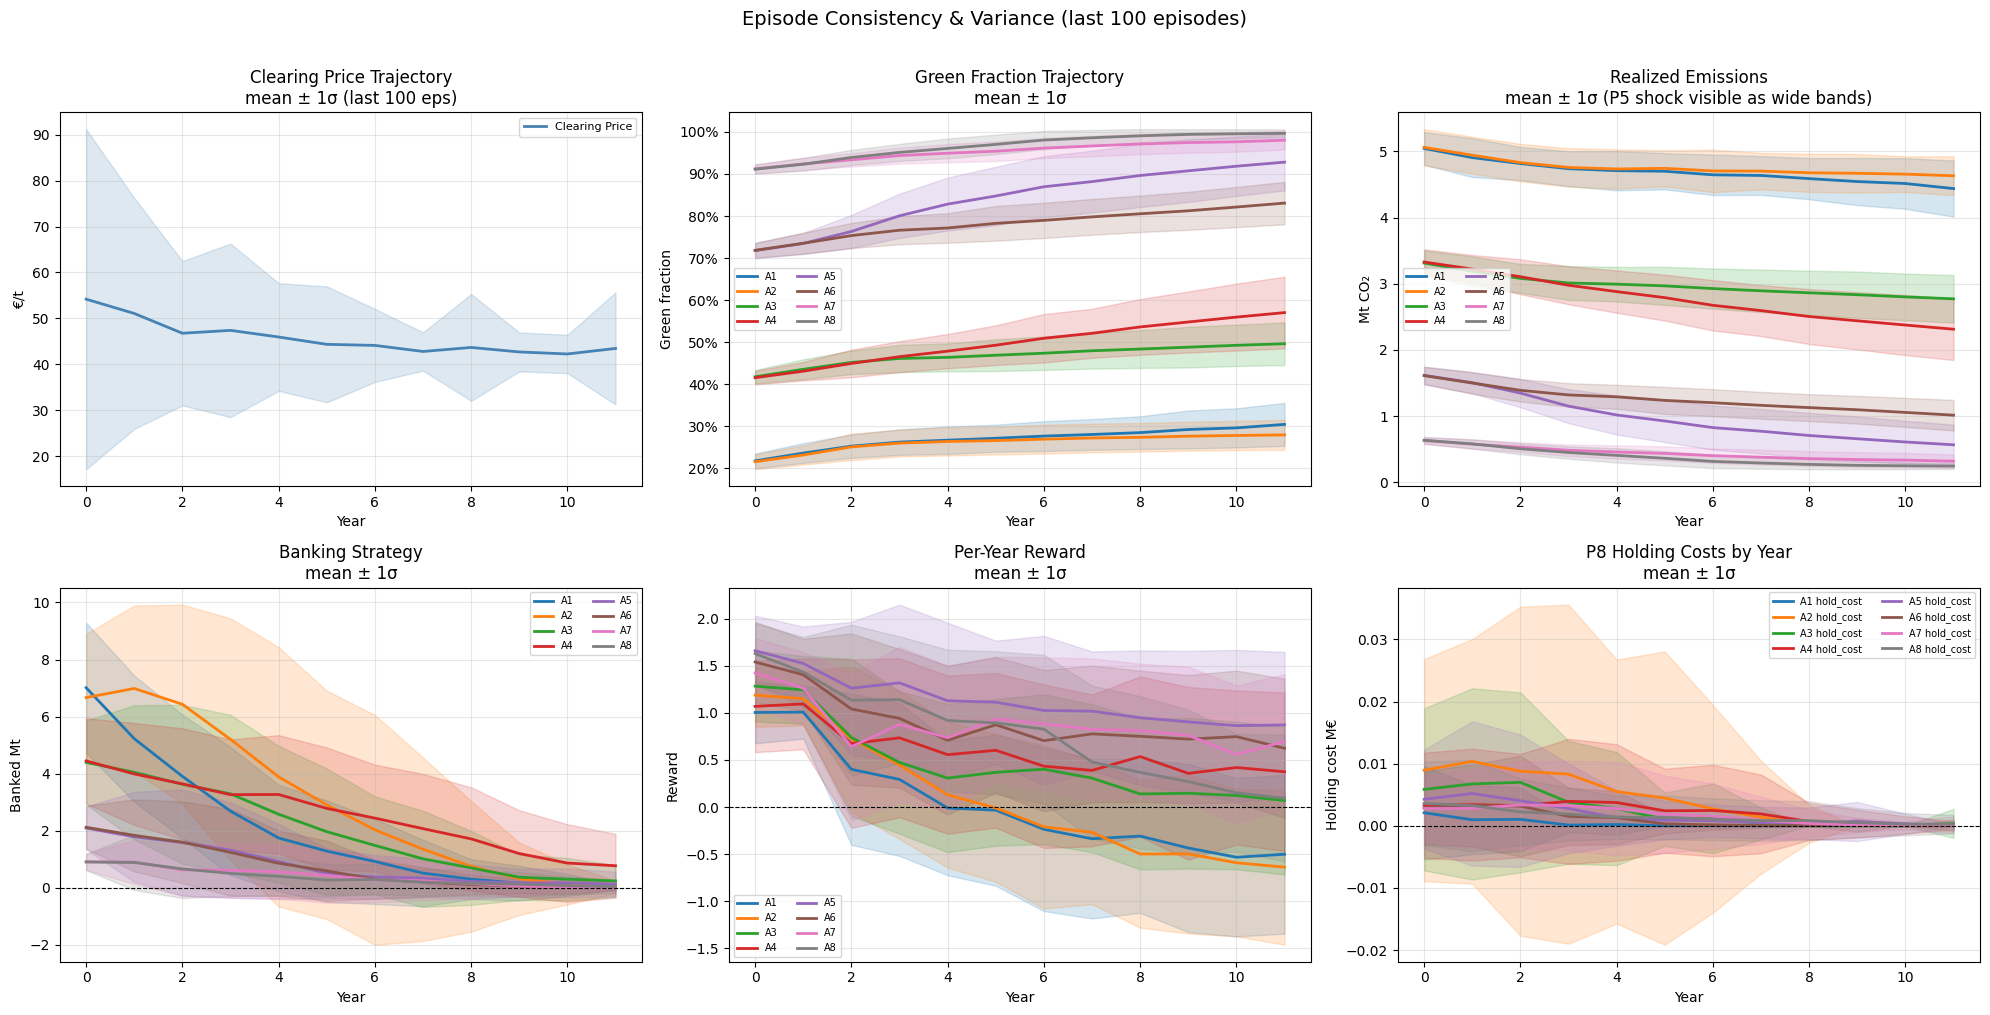


── Year-level variance summary (std across 100 episodes, mean over years) ──
    price_std (€/t)  green_frac_std  emissions_std(Mt)  bank_std(Mt)  reward_std
A1            13.79          0.0348              0.309         1.416      0.7374
A2            13.79          0.0314              0.287         2.760      0.7169
A3            13.79          0.0372              0.289         1.731      0.7206
A4            13.79          0.0513              0.347         1.747      0.7891
A5            13.79          0.0584              0.280         0.960      0.6880
A6            13.79          0.0378              0.191         0.776      0.6792
A7            13.79          0.0207              0.095         0.618      0.6778
A8            13.79          0.0166              0.077         0.560      0.6796


In [14]:
# ── 6d: Episode consistency – ribbon plots (mean ± 1σ over last 100 episodes) ──
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

N_LAST = 100
last_eps = yr_df['episode'].unique()[-N_LAST:]
recent = yr_df[yr_df['episode'].isin(last_eps)].copy()
years  = sorted(recent['year'].unique())

def ribbon(ax, grp, col, color, label):
    """Plot mean ± 1 std ribbon for `col` grouped by year."""
    mu  = grp[col].mean()
    std = grp[col].std().fillna(0)
    ax.plot(mu.index, mu.values, color=color, lw=2, label=label)
    ax.fill_between(mu.index, mu - std, mu + std,
                    color=color, alpha=0.18)

grp = recent.groupby('year')
# Use a colormap that handles 8+ agents
cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i) for i in range(n_agents)]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# ── 1. Clearing price trajectory ──────────────────────────────────────────
ax = axes[0, 0]
ribbon(ax, grp, 'clearing_price', 'steelblue', 'Clearing Price')
ax.set_xlabel('Year'); ax.set_ylabel('€/t')
ax.set_title('Clearing Price Trajectory\nmean ± 1σ (last 100 eps)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# ── 2. Green fraction per agent ───────────────────────────────────────────
ax = axes[0, 1]
for i in range(n_agents):
    ribbon(ax, grp, f'green_frac_A{i+1}', agent_colors[i], f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Green fraction')
ax.set_title('Green Fraction Trajectory\nmean ± 1σ')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 3. Emissions per agent ────────────────────────────────────────────────
ax = axes[0, 2]
for i in range(n_agents):
    ribbon(ax, grp, f'emissions_A{i+1}', agent_colors[i], f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂')
ax.set_title('Realized Emissions\nmean ± 1σ (P5 shock visible as wide bands)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 4. Banking (bank_start) per agent ─────────────────────────────────────
ax = axes[1, 0]
for i in range(n_agents):
    ribbon(ax, grp, f'bank_start_A{i+1}', agent_colors[i], f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Banked Mt')
ax.set_title('Banking Strategy\nmean ± 1σ')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 5. Reward per agent ───────────────────────────────────────────────────
ax = axes[1, 1]
for i in range(n_agents):
    ribbon(ax, grp, f'reward_A{i+1}', agent_colors[i], f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Reward')
ax.set_title('Per-Year Reward\nmean ± 1σ')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 6. P8 holding cost (if logged) / shortfall ────────────────────────────
ax = axes[1, 2]
has_hcost = 'holding_cost_A1' in recent.columns
if has_hcost:
    for i in range(n_agents):
        ribbon(ax, grp, f'holding_cost_A{i+1}', agent_colors[i], f'A{i+1} hold_cost')
    ax.set_ylabel('Holding cost M€')
    ax.set_title('P8 Holding Costs by Year\nmean ± 1σ')
else:
    for i in range(n_agents):
        ribbon(ax, grp, f'shortfall_A{i+1}', agent_colors[i], f'A{i+1}')
    ax.set_ylabel('Shortfall Mt')
    ax.set_title('Shortfall by Year\nmean ± 1σ')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

plt.suptitle(f'Episode Consistency & Variance (last {N_LAST} episodes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Variance summary table ────────────────────────────────────────────────
print(f'\n── Year-level variance summary (std across {N_LAST} episodes, mean over years) ──')
var_summary = {}
for i in range(n_agents):
    var_summary[f'A{i+1}'] = {
        'price_std (€/t)':   round(recent.groupby('year')['clearing_price'].std().mean(), 2),
        'green_frac_std':    round(recent.groupby('year')[f'green_frac_A{i+1}'].std().mean(), 4),
        'emissions_std(Mt)': round(recent.groupby('year')[f'emissions_A{i+1}'].std().mean(), 3),
        'bank_std(Mt)':      round(recent.groupby('year')[f'bank_start_A{i+1}'].std().mean(), 3),
        'reward_std':        round(recent.groupby('year')[f'reward_A{i+1}'].std().mean(), 4),
    }
print(pd.DataFrame(var_summary).T.to_string())


## 7. Evaluate Best Agents (Deterministic)

In [15]:
from scripts.train import build_agents

# Load best checkpoints
eval_env = ETSEnvironment(config, seed=0)
eval_agents = build_agents(eval_env, config, seed=0)
n_agents = config['companies']['n_agents']

ckpt_dir = 'results/checkpoints_s42'
for i, agent in enumerate(eval_agents):
    ckpt_path = os.path.join(ckpt_dir, f'agent_{i}_best.pt')
    if os.path.exists(ckpt_path):
        agent.load(ckpt_path)
        print(f'Loaded agent {i}')
    else:
        print(f'No checkpoint for agent {i} — using untrained policy')

# Run deterministic evaluation
obs1, _ = eval_env.reset(seed=0)
eval_data = []

for year in range(config['simulation']['n_years']):
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_auction_action(obs1[i], deterministic=True)
        auction_actions[i] = action
    obs2, _ = eval_env.step_auction(auction_actions)

    secondary_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_secondary_action(obs2[i], deterministic=True)
        secondary_actions[i] = action

    obs1, rewards, terminated, _, info = eval_env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        for t in range(5):
            row[f'mix_A{i+1}_{tech_names[t]}'] = log['tech_mixes'][i][t]
    eval_data.append(row)
    if terminated:
        break

eval_df = pd.DataFrame(eval_data)
green_cols = ['year', 'cap', 'price'] + [f'green_A{i+1}' for i in range(n_agents)]
print(eval_df[green_cols].to_string(index=False))

Loaded agent 0
Loaded agent 1
Loaded agent 2
Loaded agent 3
Loaded agent 4
Loaded agent 5
Loaded agent 6
Loaded agent 7
 year       cap     price  green_A1  green_A2  green_A3  green_A4  green_A5  green_A6  green_A7  green_A8
    0 24.000000 43.528778  0.225409  0.222264  0.437506  0.439117  0.700000  0.718440  0.900000  0.900000
    1 22.968000 48.256134  0.225409  0.229749  0.437506  0.439117  0.706040  0.718440  0.917404  0.900000
    2 21.980376 53.146423  0.263430  0.229749  0.437506  0.439117  0.725303  0.749830  0.929845  0.925376
    3 21.035220 60.424026  0.263430  0.268251  0.481162  0.460079  0.730683  0.756006  0.929845  0.961291
    4 20.109670 60.596050  0.263430  0.287371  0.507654  0.465708  0.730683  0.756006  0.962852  0.971246
    5 19.224845 61.159649  0.269455  0.306654  0.513616  0.472207  0.730683  0.763117  0.974899  0.989292
    6 18.378952 63.105511  0.269455  0.326608  0.513616  0.480302  0.730683  0.770155  0.985973  0.997338
    7 17.570278 61.725800  0.269

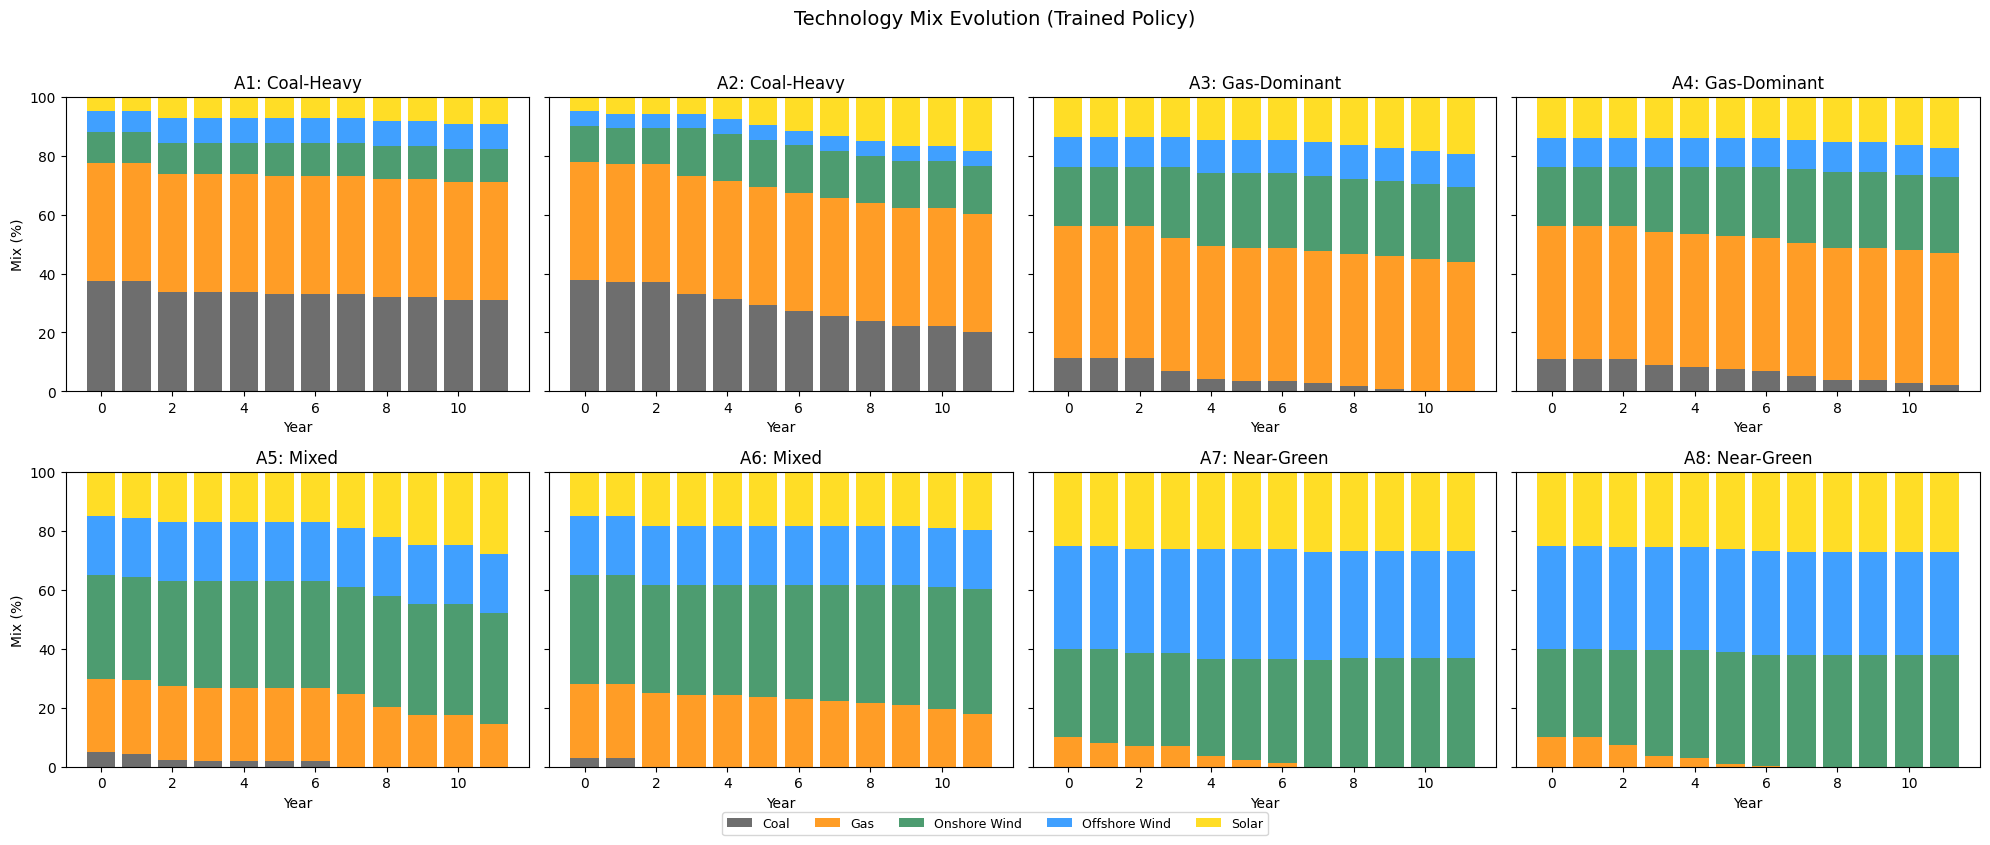

In [16]:
# Technology mix evolution per agent
tech_names = config['technologies']['names']
colors = {'coal': '#555555', 'gas': '#FF8C00', 'onshore_wind': '#2E8B57',
          'offshore_wind': '#1E90FF', 'solar': '#FFD700'}

# Dynamic archetype labels (2 of each for 8 agents)
_base_archetypes = ['Coal-Heavy', 'Gas-Dominant', 'Mixed', 'Near-Green']
archetypes = []
for arch in _base_archetypes:
    count = 0
    for mix in config['companies']['initial_mix']:
        # Match archetype by green fraction
        green = sum(mix[j] for j, g in enumerate(config['technologies']['is_green']) if g)
        if arch == 'Coal-Heavy' and green < 0.25:
            count += 1
        elif arch == 'Gas-Dominant' and 0.25 <= green < 0.55:
            count += 1
        elif arch == 'Mixed' and 0.55 <= green < 0.85:
            count += 1
        elif arch == 'Near-Green' and green >= 0.85:
            count += 1
# Simpler: just assign based on position
archetypes = []
n_per = n_agents // 4
for arch in _base_archetypes:
    for k in range(max(1, n_per)):
        archetypes.append(arch)
# Pad if needed
while len(archetypes) < n_agents:
    archetypes.append(f'Agent {len(archetypes)+1}')

ncols = min(4, n_agents)
nrows = (n_agents + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharey=True)
axes = np.atleast_1d(axes).flatten()

for i in range(n_agents):
    ax = axes[i]
    bottom = np.zeros(len(eval_df))
    for t in range(5):
        vals = eval_df[f'mix_A{i+1}_{tech_names[t]}'].values * 100
        ax.bar(eval_df['year'], vals, bottom=bottom,
               label=tech_names[t].replace('_', ' ').title(),
               color=colors[tech_names[t]], alpha=0.85)
        bottom += vals
    ax.set_xlabel('Year')
    if i % ncols == 0:
        ax.set_ylabel('Mix (%)')
    ax.set_title(f'A{i+1}: {archetypes[i]}')
    ax.set_ylim(0, 100)

# Hide unused axes
for j in range(n_agents, len(axes)):
    axes[j].set_visible(False)

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Technology Mix Evolution (Trained Policy)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Investment Cost Sanity Check

Verify that investment costs match real-world data (action plan §2).

In [17]:
env = ETSEnvironment(config, seed=42)
env.reset()
c = env.companies[0]  # A1: coal-heavy

print('=== Investment Cost Sanity Check ===')
print(f'Company output: {c.output_twh} TWh/year = {c.output_mwh/1e6:.0f} million MWh')
print()

for tech_idx, name in [(2, 'Onshore Wind'), (3, 'Offshore Wind'), (4, 'Solar PV')]:
    frac = 0.03  # 3% of output
    delta_mwh = frac * c.output_mwh
    cf = c.capacity_factors[tech_idx]
    delta_mw = delta_mwh / (cf * 8760)
    cost = c.compute_investment_cost(tech_idx, frac)
    print(f'{name}:')
    print(f'  Shift: {frac*100:.0f}% = {delta_mwh/1e6:.0f} GWh/yr')
    print(f'  New capacity: {delta_mw:.0f} MW (at CF={cf:.0%})')
    print(f'  CapEx: {c.capex[tech_idx]:.0f} €/kW')
    print(f'  Investment cost: {cost:.1f} M€')
    print()

=== Investment Cost Sanity Check ===
Company output: 10.0 TWh/year = 10 million MWh

Onshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 98 MW (at CF=35%)
  CapEx: 1350 €/kW
  Investment cost: 132.7 M€

Offshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 73 MW (at CF=47%)
  CapEx: 3250 €/kW
  Investment cost: 237.7 M€

Solar PV:
  Shift: 3% = 0 GWh/yr
  New capacity: 201 MW (at CF=17%)
  CapEx: 750 €/kW
  Investment cost: 152.6 M€



## 9. Full Training Run (Longer)

Uncomment and run for a more complete training. Takes ~15-30 min on Colab GPU.

In [18]:
# Full training
import copy
from scripts.train import train_one_seed

full_config = copy.deepcopy(config)
full_config['simulation']['n_episodes'] = 15000
full_config['logging']['log_interval'] = 97
full_config['logging']['results_dir'] = 'results/'

train_one_seed(full_config, seed=42)



Training — seed 42, 8 agents, PPO, two-phase
v5.0: MAC switching | Electricity revenue | Carry-forward
P1-P8 + structural improvements active

──────────────────────────────────────────────────────────────────────────────────
TRAINING CONSOLE — COLUMN GUIDE
──────────────────────────────────────────────────────────────────────────────────
Market header  (printed every log_interval episodes)
  price X→Y (peak Z) : ETS clearing price yr-0 → yr-N and peak  (€/t)
  cap                : Cap (Mt) in the final year
  TNAC               : Total allowances in circulation, final year
  sec_price/vol/match: Secondary market stats
  entropy/shaping    : PPO entropy coef & green-shaping weight
  [ENT-DECAY]        : Entropy decay triggered
  [cyc=Ax]           : Active agent (soft cycling)

Per-agent columns
  Green(0→N)  : Green fraction trajectory
  ΔGreen      : Net green change (pp)
  AvgEmiss    : Mean emissions (Mt)
  AvgAlloc    : Mean allocation (Mt)
  SfYrs       : Shortfall years
  AvgBi